# 港股高回购低波动策略 (High Repurchase Low Volatility Strategy)

## 策略简介
本策略依托于 **HSCI (恒生综合指数)** 股票池，使用公司回购行为替代分红行为，旨在筛选出持续进行股权回购、良好流动性，且具有较低市场波动率的港股优质标的。在长周期回测中获取稳定的超额收益与更优的风险回报比（Sharpe Ratio）。

## 选股逻辑
在每个调仓日，我们将对 HSCI 股票池中的标的执行以下筛选与排序：

1. **基本面与数据完整性**：
   - 剔除缺失核心月频因子（如近一年波动率、近三月成交额等）的数据。
2. **回购考察**：
   - 在过去 36 个月中，要求标的必须有回购记录（过去三年累计回购金额 > 0）。
3. **流动性与规模双重过滤 (Top 70%)**：
   - 动态计算该期个股的**近 3 个月日均成交额**和**总市值**。
   - **剔除**：成交额位列倒数 30% 或者市值位列倒数 30% 的尾部股票。
4. **极端值清洗**：
   - 将得分排在全市场前 `0.1%` 的极端异常高回购率样本剔除，防止“数据陷阱”。
5. **核心排序因子 (回购率)**：
   - 计算因子： $\frac{\text{近三年每股总回购金额}}{\text{当前股价}}$ （在计算上等同于 $\frac{\text{近三年总回购金额}}{\text{当前总市值}}$ ）。
   - 取该评分排名前 `35%` 的标的进入最终备选池。
6. **低波动精选**：
   - 近一年日收益率年化波动率 (`volatility`) 最低的 **10 ~ 15 只**个股作为最终持仓。

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")

# 1. 加载回购数据
buyback = pd.read_csv('data/em_buyback_filtered.csv')
buyback['date'] = pd.to_datetime(buyback['日期'])
# 转换股票代码为 sid: e.g. 00314 -> 0314.HK, 有些可能没有前导0，需要zfill
# 先确保它是字符串，补充到5位（港股通通常5位代码，如00314），然后取后四位+'.HK'
buyback['sid'] = buyback['股票代码'].astype(str).str.zfill(5).str[1:5] + '.HK'
buyback['date_m'] = buyback['date'].dt.to_period('M')

# 计算每月的总回购金额
monthly_buyback = buyback.groupby(['date_m', 'sid'])['回购总额'].sum().reset_index()
monthly_buyback_pivot = monthly_buyback.pivot(index='date_m', columns='sid', values='回购总额').fillna(0)

# --- 后端回测计算 ---
print("Loading data for Backtest...")

price_cols = pd.read_csv('data/hk_price.csv', usecols=['date', 'sid', 'close', 'AdjClose'])
price_cols['date'] = pd.to_datetime(price_cols['date'])
price_cols['date_m'] = price_cols['date'].dt.to_period('M')

monthly_price = price_cols.sort_values('date').groupby(['date_m', 'sid']).last().reset_index()
monthly_price_pivot = monthly_price.pivot(index='date_m', columns='sid', values='AdjClose')
monthly_ret = monthly_price_pivot.pct_change(fill_method=None).shift(-1) 

with pd.HDFStore('data/hk_shares.h5') as store:
    shares = store.get(store.keys()[0]).reset_index()

shares['sid'] = shares['order_book_id'].str[1:5] + '.HK'
shares['date_m'] = pd.to_datetime(shares['date']).dt.to_period('M')
shares_monthly = shares.sort_values('date').groupby(['date_m', 'sid']).last().reset_index()

mcap_df = pd.merge(monthly_price[['date_m', 'sid', 'close']], 
                   shares_monthly[['date_m', 'sid', 'total']], 
                   on=['date_m', 'sid'], how='inner')
mcap_df['mcap'] = mcap_df['close'] * mcap_df['total']
mcap_pivot = mcap_df.pivot(index='date_m', columns='sid', values='mcap')

price = pd.read_csv('data/hk_price.csv', usecols=['date', 'sid', 'close', 'amount'])
price['date'] = pd.to_datetime(price['date'])

hsci = pd.read_csv('data/HSCI.csv')
hsci['date'] = pd.to_datetime(hsci['date'])
hsci['is_hsci'] = 1
hsci = hsci.drop_duplicates(subset=['date', 'sid'])
hsci['date_m'] = hsci['date'].dt.to_period('M')

print("Calculating Volatility (Low Vol)...")
price_pivot = price.pivot(index='date', columns='sid', values='close')
price_pivot = price_pivot.sort_index()
ret_pivot = price_pivot.pct_change()
vol_pivot = ret_pivot.rolling(window=252, min_periods=100).std() * np.sqrt(252)
vol_monthly = vol_pivot.resample('M').last()
vol_monthly_stacked = vol_monthly.stack().reset_index()
vol_monthly_stacked.columns = ['date', 'sid', 'volatility']
vol_monthly_stacked['date_m'] = vol_monthly_stacked['date'].dt.to_period('M')

print("Calculating Liquidity (ADTV)...")
amount_pivot = price.pivot(index='date', columns='sid', values='amount')
amount_pivot = amount_pivot.sort_index()
adv_90d_pivot = amount_pivot.rolling(window=63, min_periods=21).mean()
adv_monthly = adv_90d_pivot.resample('M').last()
adv_monthly_stacked = adv_monthly.stack().reset_index()
adv_monthly_stacked.columns = ['date', 'sid', 'adtv_3m']
adv_monthly_stacked['date_m'] = adv_monthly_stacked['date'].dt.to_period('M')

print("Generating 3-Year Rolling Buyback Amount...")
monthly_buyback_pivot = monthly_buyback_pivot.sort_index()
# 滚动求过去36个月（包含当月）的回购总额
buyback_36m_pivot = monthly_buyback_pivot.rolling(window=36, min_periods=12).sum()
buyback_36m_stacked = buyback_36m_pivot.stack().reset_index()
buyback_36m_stacked.columns = ['date_m', 'sid', 'buyback_36m']

print("Merging factors and generating signals...")
df_factors = buyback_36m_stacked.merge(
    vol_monthly_stacked[['date_m', 'sid', 'volatility']], on=['date_m', 'sid'], how='inner'
).merge(
    adv_monthly_stacked[['date_m', 'sid', 'adtv_3m']], on=['date_m', 'sid'], how='inner'
).merge(
    mcap_df[['date_m', 'sid', 'mcap']], on=['date_m', 'sid'], how='inner'
).merge(
    hsci[['date_m', 'sid', 'is_hsci']], on=['date_m', 'sid'], how='inner'
)
df_factors = df_factors.drop_duplicates(subset=['date_m', 'sid'])

Loading data...
Loading data for Backtest...
Calculating Volatility (Low Vol)...
Calculating Liquidity (ADTV)...
Generating 3-Year Rolling Buyback Amount...
Merging factors and generating signals...


In [40]:
# 全局字典记录基础池子（剔除后但未排序前）的股票数量
pool_sizes_record = {}

def select_stocks(group):
    current_m = group['date_m'].iloc[0]

    # a. 必须在过去3年内有回购（回购总额>0）
    pool = group[group['buyback_36m'] > 0]

    # b. 流动性与市值过滤：成交量和市值均在当月全体股票（group）的前70%（即 >= 30%分位数）
    if len(group) > 0:
        adtv_threshold = group['adtv_3m'].quantile(0.2)
        mcap_threshold = group['mcap'].quantile(0.2)
        pool = pool[(pool['adtv_3m'] >= adtv_threshold) & (pool['mcap'] >= mcap_threshold)]
    
    pool_sizes_record[current_m] = len(pool)

    if len(pool) == 0:
        return []

    pool = pool.copy()
    
    # c. 计算核心指标：近三年总回购金额 / 当前市值
    # 此逻辑等价于 近三年每股总回购金额 / 股价
    pool['score'] = pool['buyback_36m'] / pool['mcap']
    pool = pool.dropna(subset=['score'])

    if len(pool) == 0:
        return []

    # 先剔除得分最高0.1%（避免极端伪高回购收益率样本）
    cutoff = pool['score'].quantile(0.999)
    pool = pool[pool['score'] <= cutoff]

    if len(pool) == 0:
        return []

    # 前35%或最少20只
    n_top = max(20, int(len(pool) * 0.35)) 
    pool = pool.nlargest(n_top, 'score')
    
    # e. 选取波动率最低的15只作为最终持仓
    n_final = min(20, len(pool))
    final_pool = pool.nsmallest(n_final, 'volatility')
    
    return final_pool['sid'].tolist()

pool_sizes_record.clear()

print("Stock Selection applying (Method: 3-Year Buyback Yield)...")
signals = df_factors.groupby('date_m').apply(select_stocks)

# 计算并打印持仓数量与候选池数量
avg_eligible_pool_size = np.mean(list(pool_sizes_record.values())) if pool_sizes_record else 0
lengths = signals.apply(len)

print(f"\n=======================================================")
print(f"Average number of stocks in ELIGIBLE POOL (before ranking & picking): {avg_eligible_pool_size:.1f}")
print(f"=======================================================\n")
print(f"Average selected portfolio size: {lengths.mean():.1f}")

print("\nRecent Stock Selections (Last 3 months):")
for period in signals.index[-3:]:
    print(f"{period}: {signals.loc[period]}")

Stock Selection applying (Method: 3-Year Buyback Yield)...

Average number of stocks in ELIGIBLE POOL (before ranking & picking): 87.6

Average selected portfolio size: 20.0

Recent Stock Selections (Last 3 months):
2025-07: ['1113.HK', '0005.HK', '0019.HK', '0386.HK', '2888.HK', '0700.HK', '1299.HK', '1513.HK', '1919.HK', '9987.HK', '3898.HK', '2331.HK', '1910.HK', '1157.HK', '2343.HK', '2333.HK', '2319.HK', '0772.HK', '3888.HK', '2096.HK']
2025-08: ['0005.HK', '1113.HK', '0019.HK', '0386.HK', '2888.HK', '0700.HK', '1299.HK', '1513.HK', '1919.HK', '0656.HK', '9987.HK', '3898.HK', '1910.HK', '2331.HK', '1157.HK', '1378.HK', '2343.HK', '1579.HK', '9699.HK', '2319.HK']
2025-09: ['1113.HK', '0005.HK', '0019.HK', '0386.HK', '1299.HK', '0700.HK', '1513.HK', '1919.HK', '0656.HK', '9987.HK', '3898.HK', '1910.HK', '2331.HK', '1157.HK', '1579.HK', '2343.HK', '1378.HK', '2319.HK', '9699.HK', '2333.HK']


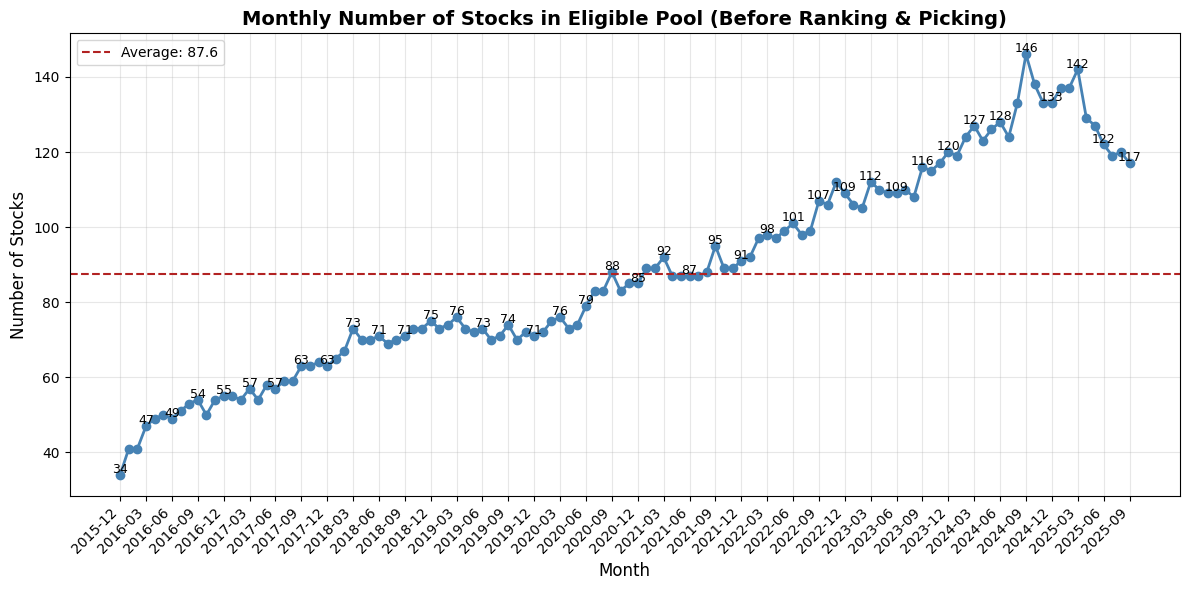

图表已保存为 'eligible_pool_trend.png'


<Figure size 640x480 with 0 Axes>

In [41]:
# 绘制每月合格池股票数量的变化
import matplotlib.pyplot as plt
import numpy as np

# 获取数据并确保月份为字符串格式
months = [str(month) for month in pool_sizes_record.keys()]
counts = list(pool_sizes_record.values())

# 创建图表
plt.figure(figsize=(12, 6))
plt.plot(months, counts, marker='o', linestyle='-', linewidth=2, color='steelblue')
plt.title('Monthly Number of Stocks in Eligible Pool (Before Ranking & Picking)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Stocks', fontsize=12)

# 设置x轴刻度：每隔3个月显示一次标签
plt.xticks(range(0, len(months), 3), 
           [months[i] for i in range(0, len(months), 3)], 
           rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 添加平均线
avg_count = np.mean(counts) if counts else 0
plt.axhline(y=avg_count, color='firebrick', linestyle='--', linewidth=1.5, 
           label=f'Average: {avg_count:.1f}')

# 添加数据点标签
for i, (month, count) in enumerate(zip(months, counts)):
    if i % 3 == 0 or i == len(months)-1:  # 每隔3个月或最后一个月显示标签
        plt.text(i, count+0.5, str(count), ha='center', fontsize=9)

plt.legend()
plt.show()

# 保存图表
plt.savefig('eligible_pool_trend.png', dpi=300, bbox_inches='tight')
print("图表已保存为 'eligible_pool_trend.png'")

Running Backtest...
Backtest finished. (Rebalance every 3 month(s), 118 periods)


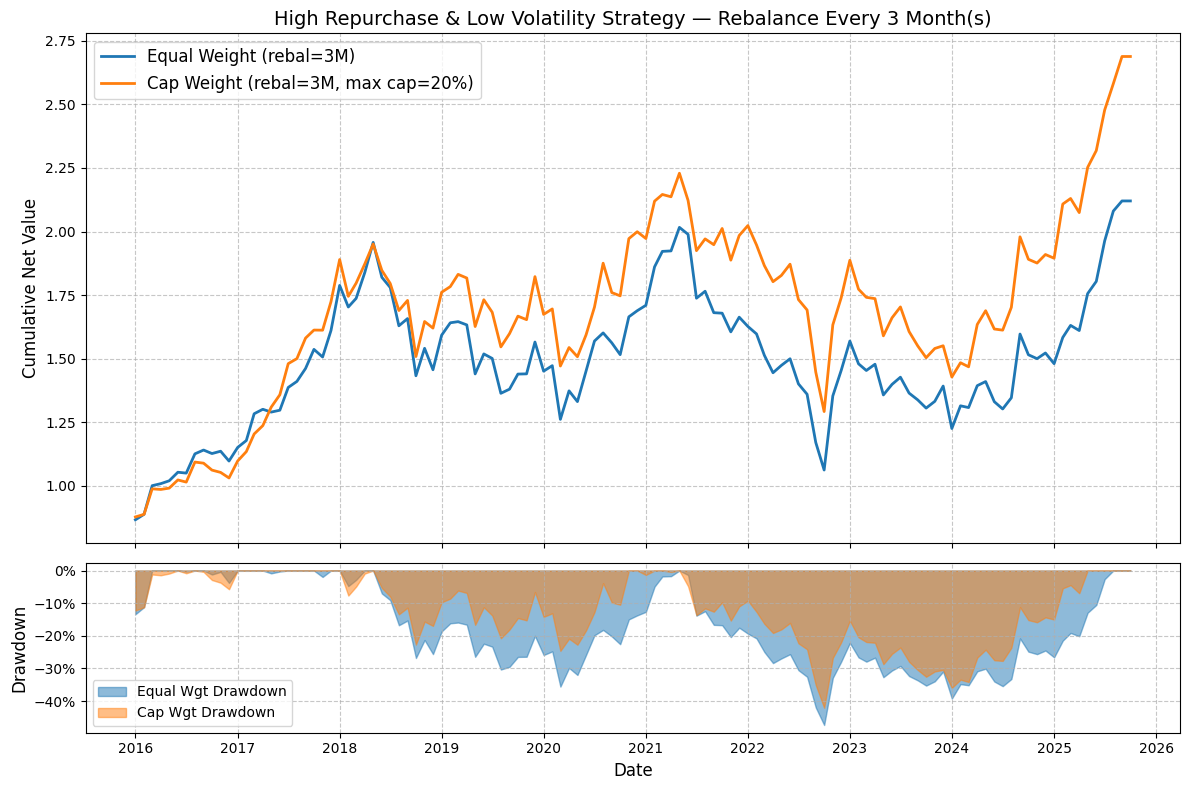


--- Performance Metrics ---
Metric               | Equal Weight    | Cap Weight     
-------------------------------------------------------
Annualized Return    | 10.17%        | 12.48%
Annualized Vol       | 22.62%        | 22.06%
Sharpe Ratio         | 0.45             | 0.57
Max Drawdown         | -47.33%        | -42.04%


In [42]:
# --- 运行回测 ---
print("Running Backtest...")

# ========== 参数设置 ==========
BACKTEST_START   = pd.Period('2012-01', 'M')
REBALANCE_FREQ   = 3   # 调仓频率（月），1=每月调仓，3=季度，6=半年，12=年度
MAX_WEIGHT_LIMIT = 0.2 # 市值加权的单一个股权重上限，例如 0.2 表示最高20%
# ==============================

dates = signals.index[signals.index >= BACKTEST_START]

portfolio_ret_eq = []
portfolio_ret_cw = []
valid_dates = []

current_stocks = []   
rebalance_count = 0   

for t_idx, date_m in enumerate(dates):
    if date_m not in monthly_ret.index:
        continue

    if t_idx % REBALANCE_FREQ == 0:
        new_stocks = signals.loc[date_m]
        if len(new_stocks) > 0:
            current_stocks = new_stocks

    if len(current_stocks) == 0:
        continue

    nxt_ret = monthly_ret.loc[date_m].reindex(current_stocks).fillna(0)

    # 1. 等权配置 (Equal Weight)
    eq_weights = np.ones(len(current_stocks)) / len(current_stocks)
    ret_eq = np.sum(eq_weights * nxt_ret.values)

    # 2. 市值加权 (Cap Weight) 
    if date_m in mcap_pivot.index:
        mcap_vals = mcap_pivot.loc[date_m].reindex(current_stocks).fillna(0)
        total_mcap = mcap_vals.sum()
        if total_mcap > 0:
            cw_weights = mcap_vals / total_mcap
            
            if MAX_WEIGHT_LIMIT is not None and MAX_WEIGHT_LIMIT < 1.0:
                while (cw_weights > MAX_WEIGHT_LIMIT + 1e-6).any():
                    cw_weights[cw_weights > MAX_WEIGHT_LIMIT] = MAX_WEIGHT_LIMIT
                    
                    mask = cw_weights < MAX_WEIGHT_LIMIT
                    if not mask.any():
                        break 
                    remaining_weight = 1.0 - cw_weights[~mask].sum()
                    
                    if remaining_weight <= 0:
                        break
                        
                    cw_weights[mask] = cw_weights[mask] / cw_weights[mask].sum() * remaining_weight

            ret_cw = np.sum(cw_weights.values * nxt_ret.values)
        else:
            ret_cw = ret_eq
    else:
        ret_cw = ret_eq

    portfolio_ret_eq.append(ret_eq)
    portfolio_ret_cw.append(ret_cw)
    valid_dates.append(date_m)

df_bt = pd.DataFrame({
    'date': valid_dates,
    'Equal_Weight_Returns': portfolio_ret_eq,
    'Cap_Weight_Returns': portfolio_ret_cw
})
df_bt['date_return'] = df_bt['date'].apply(lambda x: x + 1)
df_bt.set_index('date_return', inplace=True)

df_bt['Equal_Weight_NetValue'] = (1 + df_bt['Equal_Weight_Returns']).cumprod()
df_bt['Cap_Weight_NetValue']   = (1 + df_bt['Cap_Weight_Returns']).cumprod()

print(f"Backtest finished. (Rebalance every {REBALANCE_FREQ} month(s), {len(df_bt)} periods)")

# --- 绘制收益曲线与回撤 ---
index_dates = df_bt.index.to_timestamp()

eq_dd = df_bt['Equal_Weight_NetValue'] / df_bt['Equal_Weight_NetValue'].cummax().clip(lower=1.0) - 1
cw_dd = df_bt['Cap_Weight_NetValue']   / df_bt['Cap_Weight_NetValue'].cummax().clip(lower=1.0)   - 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(index_dates, df_bt['Equal_Weight_NetValue'], label=f'Equal Weight (rebal={REBALANCE_FREQ}M)', linewidth=2)
ax1.plot(index_dates, df_bt['Cap_Weight_NetValue'],   label=f'Cap Weight (rebal={REBALANCE_FREQ}M, max cap={MAX_WEIGHT_LIMIT*100:.0f}%)',   linewidth=2)
ax1.set_title(f'High Repurchase & Low Volatility Strategy — Rebalance Every {REBALANCE_FREQ} Month(s)', fontsize=14)
ax1.set_ylabel('Cumulative Net Value', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=12, loc='upper left')

import matplotlib.ticker as mtick
ax2.fill_between(index_dates, eq_dd, 0, alpha=0.5, label='Equal Wgt Drawdown', color='tab:blue')
ax2.fill_between(index_dates, cw_dd, 0, alpha=0.5, label='Cap Wgt Drawdown',   color='tab:orange')
ax2.set_ylabel('Drawdown', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(fontsize=10, loc='lower left')

plt.tight_layout()
plt.show()

# 打印绩效指标
def calc_metrics(returns):
    ann_ret = returns.mean() * 12
    ann_vol = returns.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else np.nan
    cum_ret = (1 + returns).cumprod()
    max_dd  = (cum_ret / cum_ret.cummax().clip(lower=1.0) - 1).min()
    return ann_ret, ann_vol, sharpe, max_dd

eq_ann_ret, eq_ann_vol, eq_sharpe, eq_mdd = calc_metrics(df_bt['Equal_Weight_Returns'])
cw_ann_ret, cw_ann_vol, cw_sharpe, cw_mdd = calc_metrics(df_bt['Cap_Weight_Returns'])

print("\n--- Performance Metrics ---")
print(f"{'Metric':<20} | {'Equal Weight':<15} | {'Cap Weight':<15}")
print("-" * 55)
print(f"{'Annualized Return':<20} | {eq_ann_ret:.2%} {'':<6} | {cw_ann_ret:.2%}")
print(f"{'Annualized Vol':<20} | {eq_ann_vol:.2%} {'':<6} | {cw_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<20} | {eq_sharpe:.2f} {'':<11} | {cw_sharpe:.2f}")
print(f"{'Max Drawdown':<20} | {eq_mdd:.2%} {'':<6} | {cw_mdd:.2%}")

In [43]:
import numpy as np
from scipy import stats

# 读取Fama-French三因子数据
ff3 = pd.read_csv('data/hk_ff3_factors.csv')
ff3['date_m'] = pd.to_datetime(ff3['date_m']).dt.to_period('M')
ff3.set_index('date_m', inplace=True)

# 对齐时间索引
common_dates = df_bt.index.intersection(ff3.index)
y = df_bt.loc[common_dates, 'Cap_Weight_Returns'].astype(float)
X = ff3.loc[common_dates, ['MKT', 'SMB', 'HML']].astype(float)

# 加入常数项
X = np.column_stack([np.ones(len(X)), X.values])

# OLS 回归
beta, _, _, _ = np.linalg.lstsq(X, y.values, rcond=None)
y_hat = X @ beta
resid = y.values - y_hat

n, k = X.shape
df_resid = n - k
sigma2 = (resid @ resid) / df_resid
cov_beta = sigma2 * np.linalg.inv(X.T @ X)
se_beta = np.sqrt(np.diag(cov_beta))

t_vals = beta / se_beta
p_vals = 2 * stats.t.sf(np.abs(t_vals), df_resid)

alpha = beta[0]
alpha_t = t_vals[0]
p_value = p_vals[0]

print("\n--- FF3 Regression Results ---")
print(f"Alpha (monthly): {alpha:.4%}")
print(f"Alpha t-stat:    {alpha_t:.4f}")
print(f"Alpha p-value:   {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Alpha IS statistically significant at 5% level.")
else:
    print("Conclusion: Alpha is NOT statistically significant at 5% level.")


--- FF3 Regression Results ---
Alpha (monthly): 0.6688%
Alpha t-stat:    2.8514
Alpha p-value:   0.0052
Conclusion: Alpha IS statistically significant at 5% level.


In [44]:
# === 单纯的回购因子与多空策略验证 (引入无回购组 Q0 + 设上限的市值加权) ===
# %pip install -q --upgrade scipy statsmodels

import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats

print("Grouping by Pure Buyback Yield Factor with Q0...")

portfolio_returns_eq = []
portfolio_returns_cw = []
portfolio_counts_q = []

for date_m, group in df_factors.groupby('date_m'):
    if date_m not in monthly_ret.index:
        continue
        
    # 1. 先进行整体的流动性与市值过滤 (Top 70%)
    if len(group) > 0:
        adtv_threshold = group['adtv_3m'].quantile(0.2)
        mcap_threshold = group['mcap'].quantile(0.2)
        valid_pool = group[(group['adtv_3m'] >= adtv_threshold) & (group['mcap'] >= mcap_threshold)].copy()
    else:
        continue
        
    if len(valid_pool) < 10: # 样本太少不足以稳定分组
        continue
        
    # 2. 划分为“无回购组(Q0)”和“有回购组(待分Q1-Q5)”
    pool_zero = valid_pool[valid_pool['buyback_36m'].fillna(0) <= 0].copy()
    pool_pos  = valid_pool[valid_pool['buyback_36m'].fillna(0) > 0].copy()
    
    # Q0 直接赋值
    pool_zero['quintile'] = 'Q0'
    
    if len(pool_pos) < 5:
        continue
        
    # 3. 对有回购的组进行回购率计算并五分组
    pool_pos['score'] = pool_pos['buyback_36m'] / pool_pos['mcap']
    
    # 剔除极值 (沿用之前指定的分位数剔除法)
    lower_cutoff = pool_pos['score'].quantile(0.05)
    upper_cutoff = pool_pos['score'].quantile(0.95)
    pool_pos = pool_pos[(pool_pos['score'] >= lower_cutoff) & (pool_pos['score'] <= upper_cutoff)]

    if len(pool_pos) < 5:
        continue
        
    # 按回购因子(score)均分为5组 (Q1 回购率最低, Q5 回购率最高)
    try:
        pool_pos['quintile'] = pd.qcut(pool_pos['score'].rank(method='first'), 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    except ValueError:
        continue
    
    # 合并有回购和无回购的池子
    combined_pool = pd.concat([pool_zero, pool_pos])
    
    # 获取下个月收益率
    nxt_ret = monthly_ret.loc[date_m].replace([np.inf, -np.inf], np.nan)
    
    ret_eq_dict = {'date_return': date_m + 1}
    ret_cw_dict = {'date_return': date_m + 1}
    count_dict = {'date_return': date_m + 1}
    
    for q in ['Q0', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5']:
        sids = combined_pool[combined_pool['quintile'] == q]['sid']
        count_dict[q] = len(sids)
        if len(sids) > 0:
            nxt_ret_sids = nxt_ret.reindex(sids).fillna(0)
            
            # 1. 等权计算
            ret_eq_dict[q] = nxt_ret_sids.mean() 
            
            # 2. 限制权重的市值加权计算 (上限 15%)
            if date_m in mcap_pivot.index:
                mcap_vals = mcap_pivot.loc[date_m].reindex(sids).fillna(0)
                total_mcap = mcap_vals.sum()
                if total_mcap > 0:
                    cw_weights = mcap_vals / total_mcap
                    
                    # --- 加入个股权重 15% 上限限制循环 ---
                    MAX_WEIGHT_LIMIT = 0.15
                    while (cw_weights > MAX_WEIGHT_LIMIT + 1e-6).any():
                        cw_weights[cw_weights > MAX_WEIGHT_LIMIT] = MAX_WEIGHT_LIMIT
                        
                        mask = cw_weights < MAX_WEIGHT_LIMIT
                        if not mask.any():
                            break 
                        remaining_weight = 1.0 - cw_weights[~mask].sum()
                        
                        if remaining_weight <= 0:
                            break
                            
                        cw_weights[mask] = cw_weights[mask] / cw_weights[mask].sum() * remaining_weight
                    # -----------------------------------
                    
                    ret_cw_dict[q] = np.sum(cw_weights.values * nxt_ret_sids.values)
                else:
                    ret_cw_dict[q] = ret_eq_dict[q]
            else:
                ret_cw_dict[q] = ret_eq_dict[q]
        else:
            ret_eq_dict[q] = 0.0
            ret_cw_dict[q] = 0.0
            
    portfolio_returns_eq.append(ret_eq_dict)
    portfolio_returns_cw.append(ret_cw_dict)
    portfolio_counts_q.append(count_dict)

# 组合收益DataFrame并添加多空列的函数
def process_df(df_list):
    df = pd.DataFrame(df_list).set_index('date_return')
    df['L-S (Q5-Q1)'] = df['Q5'] - df['Q1']
    df['L-S (Q5-Q0)'] = df['Q5'] - df['Q0']
    return df.replace([np.inf, -np.inf], np.nan).fillna(0)

df_q_ret_eq = process_df(portfolio_returns_eq)
df_q_ret_cw = process_df(portfolio_returns_cw)

df_q_count = pd.DataFrame(portfolio_counts_q).set_index('date_return')
df_q_count['L-S (Q5-Q1)'] = df_q_count['Q5'] + df_q_count['Q1']
df_q_count['L-S (Q5-Q0)'] = df_q_count['Q5'] + df_q_count['Q0']

# --- 准备 FF3 数据 ---
ff3 = pd.read_csv('data/hk_ff3_factors.csv')
ff3['date_m'] = pd.to_datetime(ff3['date_m']).dt.to_period('M')
ff3.set_index('date_m', inplace=True)

# 封装打印汇总表的函数
def analyze_portfolios(df_ret, df_count, title_prefix):
    mean_ret = df_ret.mean() * 100 
    mean_count = df_count.mean()
    n_obs = len(df_ret)

    t_stats = []
    p_vals = []

    for port in df_ret.columns:
        y_port = df_ret[port].dropna() * 100
        if len(y_port) > 3:
            X_const = np.ones(len(y_port))
            mod = sm.OLS(y_port, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
            t_stats.append(mod.tvalues[0])
            p_vals.append(mod.pvalues[0])
        else:
            t_stats.append(np.nan)
            p_vals.append(np.nan)

    t_stats = pd.Series(t_stats, index=df_ret.columns)
    p_vals = pd.Series(p_vals, index=df_ret.columns)

    star_list = []
    for p in p_vals:
        if p < 0.01: star_list.append('***')
        elif p < 0.05: star_list.append('**')
        elif p < 0.1: star_list.append('*')
        else: star_list.append('')

    df_summary = pd.DataFrame({
        'Avg Monthly Ret (%)': [f"{m:.3f} {s}" for m, s in zip(mean_ret, star_list)],
        'T-stat (NW)': t_stats.round(3),
        'p-value (NW)': np.round(p_vals, 4)
        # 'n (months)': n_obs,
        # 'n_stock (avg)': mean_count.round(1)
    }, index=mean_ret.index)

    print(f"\n==================== {title_prefix}: Monthly Return ====================")
    print(df_summary)

    #  FF3 Alpha 计算
    common_dates = df_ret.index.intersection(ff3.index)
    alpha_rows = []
    for port in ['Q0', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'L-S (Q5-Q1)', 'L-S (Q5-Q0)']:
        y = df_ret.loc[common_dates, port]
        X = ff3.loc[common_dates, ['MKT', 'SMB', 'HML']]
        X = sm.add_constant(X)
        
        model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
        alpha = model.params['const'] * 100 
        p_val = model.pvalues['const']
        t_val = model.tvalues['const']
        
        stars = ''
        if p_val < 0.01: stars = '***'
        elif p_val < 0.05: stars = '**'
        elif p_val < 0.1: stars = '*'
            
        alpha_rows.append({
            'Portfolio': port,
            'Alpha (Monthly %)': f"{alpha:.3f} {stars}",
            'Alpha t-stat (NW)': round(t_val, 2),
            'p-value (NW)': round(p_val, 4)
        })

    df_alpha = pd.DataFrame(alpha_rows).set_index('Portfolio')
    print(f"\n==================== {title_prefix}: FF3 Alpha Table ====================")
    print(df_alpha)

print("\nSignificance levels: * p<0.1, ** p<0.05, *** p<0.01")
print("Q0: No Buyback | Q1 (Lowest) -> Q5 (Highest)")

# 分别计算并输出 等权(EW) 与 市值加权(CW) 的结果
analyze_portfolios(df_q_ret_eq, df_q_count, "EQUAL WEIGHT")
analyze_portfolios(df_q_ret_cw, df_q_count, "CAP WEIGHT (Max 15%)")

Grouping by Pure Buyback Yield Factor with Q0...

Significance levels: * p<0.1, ** p<0.05, *** p<0.01
Q0: No Buyback | Q1 (Lowest) -> Q5 (Highest)

==================== EQUAL WEIGHT: Monthly Return ====================
            Avg Monthly Ret (%)  T-stat (NW)  p-value (NW)
Q0                       0.475         0.775        0.4385
Q1                       0.703         1.173        0.2408
Q2                       0.713         1.112        0.2663
Q3                       0.863         1.070        0.2844
Q4                       0.455         0.656        0.5119
Q5                       1.105         1.552        0.1206
L-S (Q5-Q1)              0.403         1.157        0.2474
L-S (Q5-Q0)            0.631 **        2.359        0.0183

==================== EQUAL WEIGHT: FF3 Alpha Table ====================
            Alpha (Monthly %)  Alpha t-stat (NW)  p-value (NW)
Portfolio                                                     
Q0                     0.137                0.78   

## 扩展2：回购周期的敏感性分析及收益归因

接下来考察分别考虑 **过去1年 (12个月)、过去2年 (24个月)、过去5年 (60个月)** 的回购数据计算回购因子时，组合策略的表现差异。
并将组合超额部分根据多因子模型和基础归因进行简单拆解。


--- Running Strategy for 12-Month Buyback Horizon ---

--- Running Strategy for 24-Month Buyback Horizon ---

--- Running Strategy for 36-Month Buyback Horizon ---

--- Running Strategy for 60-Month Buyback Horizon ---


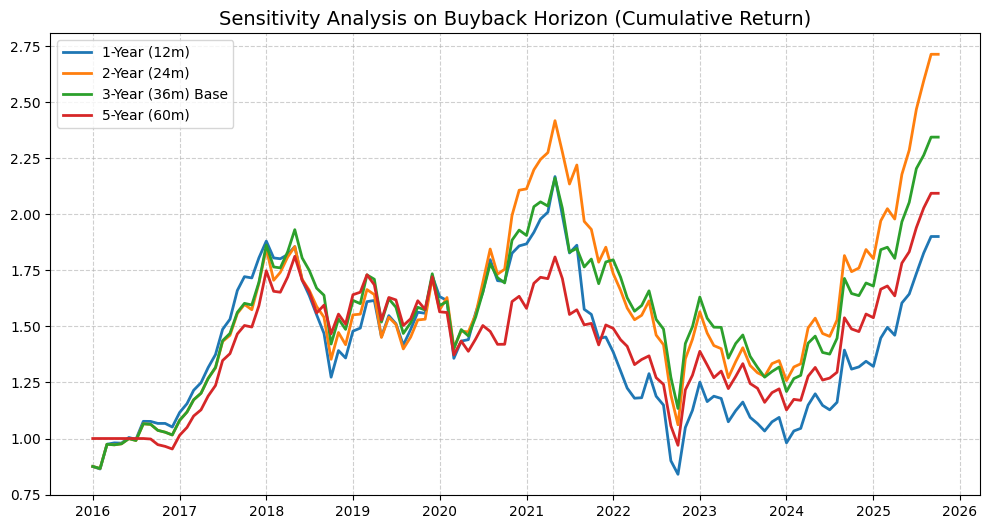


--- FF3 Attribution by Horizon ---

1-Year (12m) Horizon:
  Annual Return:  9.35%
  Annual Vol:     23.73%
  FF3 Alpha:      0.42% (t-stat: 1.60, p-val: 0.109)

2-Year (24m) Horizon:
  Annual Return:  12.92%
  Annual Vol:     23.62%
  FF3 Alpha:      0.71% (t-stat: 3.28, p-val: 0.001)

3-Year (36m) Base Horizon:
  Annual Return:  11.13%
  Annual Vol:     22.30%
  FF3 Alpha:      0.56% (t-stat: 2.87, p-val: 0.004)

5-Year (60m) Horizon:
  Annual Return:  9.51%
  Annual Vol:     20.19%
  FF3 Alpha:      0.49% (t-stat: 1.97, p-val: 0.049)


In [45]:
def run_buyback_strategy(window, monthly_buyback_pivot, df_factors_base):
    print(f"\n--- Running Strategy for {window}-Month Buyback Horizon ---")
    
    # 重新生成这 N 个月的回购总额
    buyback_n_pivot = monthly_buyback_pivot.rolling(window=window, min_periods=window//3).sum()
    buyback_n_stacked = buyback_n_pivot.stack().reset_index()
    buyback_n_stacked.columns = ['date_m', 'sid', f'buyback_{window}m']
    
    # 关联其他因子（使用现成的只包含核心列的数据集合并）
    df_merged = buyback_n_stacked.merge(
        df_factors_base, on=['date_m', 'sid'], how='inner'
    )
    
    def sel_stocks(group):
        # 必须在这几年内有回购（回购总额>0）
        pool = group[group[f'buyback_{window}m'] > 0]
        if len(pool) == 0: return []
        
        # 流动性和市值过滤 (前80%)
        adtv_thr = group['adtv_3m'].quantile(0.2)
        mcap_thr = group['mcap'].quantile(0.2)
        pool = pool[(pool['adtv_3m'] >= adtv_thr) & (pool['mcap'] >= mcap_thr)]
        if len(pool) == 0: return []
        
        pool = pool.copy()
        # 回购收益率
        pool['score'] = pool[f'buyback_{window}m'] / pool['mcap']
        
        # 截除非合理极端点
        pool = pool[pool['score'] <= pool['score'].quantile(0.999)]
        if len(pool) == 0: return []
        
        # 取评分排名前35%（或者至少20只）
        n_top = max(20, int(len(pool) * 0.35))
        pool = pool.nlargest(n_top, 'score')
        
        # 挑选波动率最低的15只
        return pool.nsmallest(min(20, len(pool)), 'volatility')['sid'].tolist()

    signals_temp = df_merged.groupby('date_m').apply(sel_stocks)
    
    # 回测计算（使用市值加权，上限15%）
    dates = signals_temp.index[signals_temp.index >= BACKTEST_START]
    port_ret = []
    
    for t_idx, date_m in enumerate(dates):
        if date_m not in monthly_ret.index:
            continue
        new_stocks = signals_temp.loc[date_m]
        
        if len(new_stocks) == 0:
            continue
            
        nxt_ret = monthly_ret.loc[date_m].reindex(new_stocks).fillna(0)
        
        if date_m in mcap_pivot.index:
            mcap_vals = mcap_pivot.loc[date_m].reindex(new_stocks).fillna(0)
            total_mcap = mcap_vals.sum()
            if total_mcap > 0:
                cw_weights = mcap_vals / total_mcap
                MAX_W = 0.15
                while (cw_weights > MAX_W + 1e-6).any():
                    cw_weights[cw_weights > MAX_W] = MAX_W
                    mask = cw_weights < MAX_W
                    if not mask.any(): break
                    adj = 1.0 - cw_weights[~mask].sum()
                    if adj <= 0: break
                    cw_weights[mask] = cw_weights[mask] / cw_weights[mask].sum() * adj
                    
                ret_cw = np.sum(cw_weights.values * nxt_ret.values)
            else:
                ret_cw = nxt_ret.mean()
        else:
            ret_cw = nxt_ret.mean()
            
        port_ret.append({'date_return': date_m + 1, 'return': ret_cw})
        
    df_res = pd.DataFrame(port_ret).set_index('date_return')
    return df_res

# 拆分基础因子数据集给敏感性分析复用
df_factors_base = df_factors[['date_m', 'sid', 'volatility', 'adtv_3m', 'mcap', 'is_hsci']]

# 分别计算 1年(12个月)、2年(24个月)、5年(60个月)
res_12m = run_buyback_strategy(12, monthly_buyback_pivot, df_factors_base)
res_24m = run_buyback_strategy(24, monthly_buyback_pivot, df_factors_base)
res_36m = run_buyback_strategy(36, monthly_buyback_pivot, df_factors_base)
res_60m = run_buyback_strategy(60, monthly_buyback_pivot, df_factors_base)

# 合并比较净值
df_comps = pd.concat([res_12m['return'].rename('1-Year (12m)'),
                      res_24m['return'].rename('2-Year (24m)'),
                      res_36m['return'].rename('3-Year (36m) Base'),
                      res_60m['return'].rename('5-Year (60m)')], axis=1).fillna(0)

nv_comps = (1 + df_comps).cumprod()

plt.figure(figsize=(12, 6))
for col in nv_comps.columns:
    plt.plot(nv_comps.index.to_timestamp(), nv_comps[col], label=col, linewidth=2)
plt.title('Sensitivity Analysis on Buyback Horizon (Cumulative Return)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 收益及Alpha表现归因
print("\n--- FF3 Attribution by Horizon ---")
common_d = df_comps.index.intersection(ff3.index)
for col in df_comps.columns:
    y = df_comps.loc[common_d, col] * 100
    X = sm.add_constant(ff3.loc[common_d, ['MKT', 'SMB', 'HML']])
    mod = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    ann_ret = (df_comps[col].mean() * 12) * 100
    ann_vol = (df_comps[col].std() * np.sqrt(12)) * 100
    print(f"\n{col} Horizon:")
    print(f"  Annual Return:  {ann_ret:.2f}%")
    print(f"  Annual Vol:     {ann_vol:.2f}%")
    print(f"  FF3 Alpha:      {mod.params['const']:.2f}% (t-stat: {mod.tvalues['const']:.2f}, p-val: {mod.pvalues['const']:.3f})")
    # print(f"  MKT Exposure:   {mod.params['MKT']:.2f} (t-stat: {mod.tvalues['MKT']:.2f})")

## 扩展3：回购收益率与波动率的双重排序 (Double Sort)

下面我们将对同时具备回购和波动率数据的样本进行独立双重分组（Independent Double Sort）。
首先按**波动率**把样本分为3组 (Low Vol, Mid Vol, High Vol)，同时按**回购因子**把有回购的样本分为3组 (Low BB, Mid BB, High BB)。
然后取两者的交集构建 3×3 = 9 个投资组合，并观察“低波动率 + 高回购”组合的表现。


--- Extending: Double Sort on Volatility and Buyback Yield (3x3) ---

=============== 3x3 Double Sort: CAP WEIGHT (Max 15%) ================

---- Summary Table ----
                  Avg Monthly Ret (%)  T-stat (NW)  p-value (NW)
Low_Vol_Low_BB                  0.850        2.038        0.0415
Low_Vol_Mid_BB                  0.465        0.917        0.3593
Low_Vol_High_BB                 0.645        1.447        0.1479
Mid_Vol_Low_BB                  0.886        1.566        0.1173
Mid_Vol_Mid_BB                  0.975        1.279        0.2009
Mid_Vol_High_BB                 1.363        1.939        0.0525
High_Vol_Low_BB                 0.767        0.902        0.3673
High_Vol_Mid_BB                 0.344        0.387        0.6990
High_Vol_High_BB                0.923        0.936        0.3495


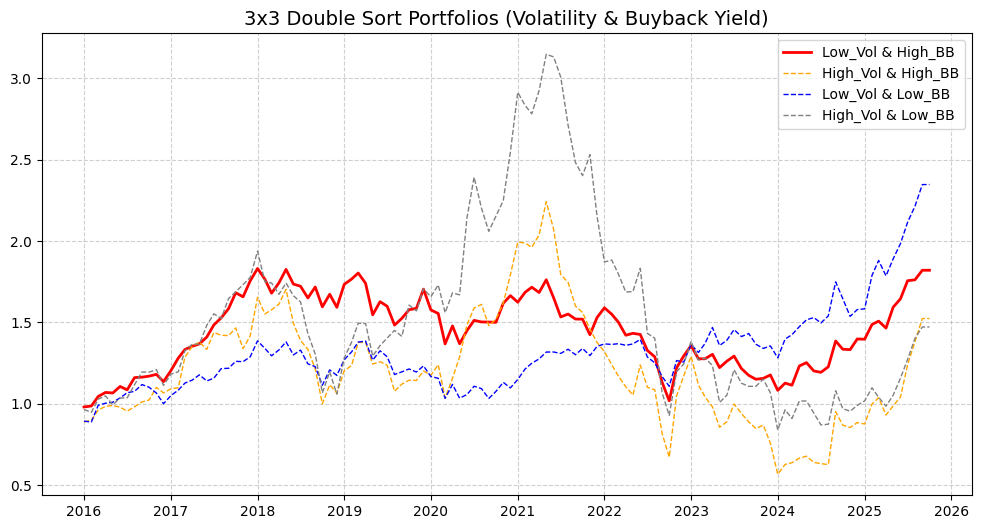

In [46]:
print("\n--- Extending: Double Sort on Volatility and Buyback Yield (3x3) ---")

portfolio_returns_ds = []

for date_m, group in df_factors.groupby('date_m'):
    if date_m not in monthly_ret.index:
        continue
        
    # 过滤流动性和市值，要有回购、要有波动率数据
    group = group.dropna(subset=['buyback_36m', 'volatility', 'mcap', 'adtv_3m']).copy()
    if len(group) == 0:
        continue
        
    adtv_threshold = group['adtv_3m'].quantile(0.2)
    mcap_threshold = group['mcap'].quantile(0.2)
    valid_pool = group[(group['adtv_3m'] >= adtv_threshold) & (group['mcap'] >= mcap_threshold)].copy()
    
    # 我们只在 "有回购" 的样本里进行双重排序，以保证两边的排序有足够的交叉样本
    pool_pos = valid_pool[valid_pool['buyback_36m'] > 0].copy()
    
    if len(pool_pos) < 9:
        continue
        
    pool_pos['bb_score'] = pool_pos['buyback_36m'] / pool_pos['mcap']
    
    # Volatility Sort (3 groups)
    try:
        pool_pos['vol_q'] = pd.qcut(pool_pos['volatility'].rank(method='first'), 3, labels=['Low_Vol', 'Mid_Vol', 'High_Vol'])
        pool_pos['bb_q'] = pd.qcut(pool_pos['bb_score'].rank(method='first'), 3, labels=['Low_BB', 'Mid_BB', 'High_BB'])
    except ValueError:
        continue
        
    nxt_ret = monthly_ret.loc[date_m].replace([np.inf, -np.inf], np.nan)
    ret_dict = {'date_return': date_m + 1}
    
    for v_q in ['Low_Vol', 'Mid_Vol', 'High_Vol']:
        for b_q in ['Low_BB', 'Mid_BB', 'High_BB']:
            sub_sids = pool_pos[(pool_pos['vol_q'] == v_q) & (pool_pos['bb_q'] == b_q)]['sid']
            name = f"{v_q}_{b_q}"
            
            if len(sub_sids) > 0:
                nxt_ret_sids = nxt_ret.reindex(sub_sids).fillna(0)
                # 简单起见，这里采用市值加权(限制上限15%)计算
                if date_m in mcap_pivot.index:
                    mcap_vals = mcap_pivot.loc[date_m].reindex(sub_sids).fillna(0)
                    total_mcap = mcap_vals.sum()
                    if total_mcap > 0:
                        cw_weights = mcap_vals / total_mcap
                        MAX_W = 0.15
                        while (cw_weights > MAX_W + 1e-6).any():
                            cw_weights[cw_weights > MAX_W] = MAX_W
                            mask = cw_weights < MAX_W
                            if not mask.any(): break
                            adj = 1.0 - cw_weights[~mask].sum()
                            if adj <= 0: break
                            cw_weights[mask] = cw_weights[mask] / cw_weights[mask].sum() * adj
                        ret_dict[name] = np.sum(cw_weights.values * nxt_ret_sids.values)
                    else:
                        ret_dict[name] = nxt_ret_sids.mean()
                else:
                    ret_dict[name] = nxt_ret_sids.mean()
            else:
                ret_dict[name] = 0.0
                
    portfolio_returns_ds.append(ret_dict)

df_ds_ret = pd.DataFrame(portfolio_returns_ds).set_index('date_return')

print("\n=============== 3x3 Double Sort: CAP WEIGHT (Max 15%) ================")

mean_ret_ds = df_ds_ret.mean() * 100 

t_stats_ds = []
p_vals_ds = []
for col in df_ds_ret.columns:
    y_port = df_ds_ret[col].dropna() * 100
    if len(y_port) > 3:
        X_const = np.ones(len(y_port))
        mod = sm.OLS(y_port, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
        t_stats_ds.append(mod.tvalues[0])
        p_vals_ds.append(mod.pvalues[0])
    else:
        t_stats_ds.append(np.nan)
        p_vals_ds.append(np.nan)

df_summary_ds = pd.DataFrame({
    'Avg Monthly Ret (%)': mean_ret_ds.round(3),
    'T-stat (NW)': pd.Series(t_stats_ds, index=df_ds_ret.columns).round(3),
    'p-value (NW)': pd.Series(p_vals_ds, index=df_ds_ret.columns).round(4)
})

# 按波动率分组展示各组的回购组收益
print("\n---- Summary Table ----")
print(df_summary_ds)

# 绘制不同组合的净值图
nv_ds = (1 + df_ds_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(nv_ds.index.to_timestamp(), nv_ds['Low_Vol_High_BB'], label='Low_Vol & High_BB', color='red', linewidth=2)
plt.plot(nv_ds.index.to_timestamp(), nv_ds['High_Vol_High_BB'], label='High_Vol & High_BB', color='orange', linewidth=1, linestyle='--')
plt.plot(nv_ds.index.to_timestamp(), nv_ds['Low_Vol_Low_BB'], label='Low_Vol & Low_BB', color='blue', linewidth=1, linestyle='--')
plt.plot(nv_ds.index.to_timestamp(), nv_ds['High_Vol_Low_BB'], label='High_Vol & Low_BB', color='gray', linewidth=1, linestyle='--')
plt.title('3x3 Double Sort Portfolios (Volatility & Buyback Yield)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## 双重排序持仓分析：Low Vol + Low BB 与 Low Vol + High BB

我们将提取上述双重分组中 **Low_Vol_Low_BB** 和 **Low_Vol_High_BB** 这两组的历次成分股，并统计在回测期间出现频率最高的标的。

In [47]:
# 收集团两组历次持仓及其收益贡献
records_ll = []
records_lh = []

# 限制市值权重函数 (与前面回测时保持一致)
def get_cw_weights(sids_subset, d_m):
    if d_m not in mcap_pivot.index:
        return np.ones(len(sids_subset))/len(sids_subset)
    m_vals = mcap_pivot.loc[d_m].reindex(sids_subset).fillna(0)
    tot = m_vals.sum()
    if tot <= 0:
        return np.ones(len(sids_subset))/len(sids_subset)
    cw = (m_vals / tot).values
    MAX_W = 0.15
    while (cw > MAX_W + 1e-6).any():
        cw[cw > MAX_W] = MAX_W
        mask = cw < MAX_W
        if not mask.any(): break
        adj = 1.0 - cw[~mask].sum()
        if adj <= 0: break
        cw[mask] = cw[mask] / cw[mask].sum() * adj
    return cw

for date_m, group in df_factors.groupby('date_m'):
    if date_m not in monthly_ret.index:
        continue
        
    group = group.dropna(subset=['buyback_36m', 'volatility', 'mcap', 'adtv_3m']).copy()
    if len(group) == 0: continue
        
    adtv_thr = group['adtv_3m'].quantile(0.2)
    mcap_thr = group['mcap'].quantile(0.2)
    valid_pool = group[(group['adtv_3m'] >= adtv_thr) & (group['mcap'] >= mcap_thr)]
    
    pool_pos = valid_pool[valid_pool['buyback_36m'] > 0].copy()
    
    if len(pool_pos) < 9: continue
        
    pool_pos['bb_score'] = pool_pos['buyback_36m'] / pool_pos['mcap']
    
    try:
        pool_pos['vol_q'] = pd.qcut(pool_pos['volatility'].rank(method='first'), 3, labels=['Low_Vol', 'Mid_Vol', 'High_Vol'])
        pool_pos['bb_q'] = pd.qcut(pool_pos['bb_score'].rank(method='first'), 3, labels=['Low_BB', 'Mid_BB', 'High_BB'])
    except ValueError:
        continue
        
    nxt_r = monthly_ret.loc[date_m].replace([np.inf, -np.inf], np.nan)
    
    # 提取 Low_Vol_Low_BB
    sids_ll = pool_pos[(pool_pos['vol_q'] == 'Low_Vol') & (pool_pos['bb_q'] == 'Low_BB')]['sid']
    if len(sids_ll) > 0:
        r_ll = nxt_r.reindex(sids_ll).fillna(0).values
        w_ll = get_cw_weights(sids_ll, date_m)
        for s, w, r in zip(sids_ll, w_ll, r_ll):
            records_ll.append({'sid': s, 'weight': w, 'ret': r, 'contrib': w * r})
            
    # 提取 Low_Vol_High_BB
    sids_lh = pool_pos[(pool_pos['vol_q'] == 'Low_Vol') & (pool_pos['bb_q'] == 'High_BB')]['sid']
    if len(sids_lh) > 0:
        r_lh = nxt_r.reindex(sids_lh).fillna(0).values
        w_lh = get_cw_weights(sids_lh, date_m)
        for s, w, r in zip(sids_lh, w_lh, r_lh):
            records_lh.append({'sid': s, 'weight': w, 'ret': r, 'contrib': w * r})

# 构建由 sid 映射到 股票名称 的字典 (从 buyback 数据表中提取)
name_map = dict(zip(buyback['sid'], buyback['股票名称']))

# 统计并打印函数
def print_top_holdings_stats(records, title):
    df_rec = pd.DataFrame(records)
    if len(df_rec) == 0: return
    
    grp = df_rec.groupby('sid').agg(
        Freq=('sid', 'count'),
        Avg_Weight=('weight', 'mean'),
        Ann_Ret=('ret', lambda x: x.mean() * 12 * 100), # 持有期年化涨幅 (%)
        Total_Contrib=('contrib', lambda x: x.sum() * 100) # 总贡献收益率 (%)
    ).sort_values('Freq', ascending=False).head(15)
    
    grp['Company Name'] = grp.index.map(lambda x: name_map.get(x, 'Unknown'))
    
    grp['Avg_Wgt'] = grp['Avg_Weight'].apply(lambda x: f"{x*100:.1f}%")
    grp['Holding_Ann_Ret'] = grp['Ann_Ret'].apply(lambda x: f"{x:.2f}%")
    grp['Total_Contrib'] = grp['Total_Contrib'].apply(lambda x: f"{x:.2f}%")
    
    print(f"============== {title} ==============")
    print(grp[['Company Name', 'Freq', 'Avg_Wgt', 'Holding_Ann_Ret', 'Total_Contrib']])
    print("\n")

print_top_holdings_stats(records_ll, "Top 15 Holdings Frequent in Low_Vol & Low_BB")
print_top_holdings_stats(records_lh, "Top 15 Holdings Frequent in Low_Vol & High_BB")

============== Top 15 Holdings Frequent in Low_Vol & Low_BB ==============
        Company Name  Freq Avg_Wgt Holding_Ann_Ret Total_Contrib
sid                                                             
0001.HK           长和    71   13.1%           4.52%         1.18%
0683.HK         嘉里建设    67    5.5%          14.93%         3.56%
0083.HK         信和置业    60   13.7%           5.23%         2.63%
0392.HK         北京控股    54    3.8%           1.67%        -2.24%
0003.HK       香港中华煤气    52   15.0%           9.94%         6.46%
1448.HK          福寿园    51    1.7%           6.80%        -0.18%
0941.HK         中国移动    44   15.0%          21.87%        12.03%
1800.HK       中国交通建设    38    6.9%           6.10%         1.08%
0006.HK         电能实业    37    6.0%          13.77%         2.59%
0883.HK       中国海洋石油    37   15.0%          34.20%        15.82%
0152.HK         深圳国际    36    6.5%          -6.92%        -1.01%
0700.HK         腾讯控股    33   15.0%          22.08%         9.11%
1088.HK        

## 结果解读与限制

当前结果里，`Low_Vol & Low_BB` 优于 `Low_Vol & High_BB`，并不意外，主要有两点原因：

1. 这里的“回购强度”定义为 `近三年总回购金额 / 当前市值`。这个口径会天然压低大市值、稳定但回购节奏不激进的公共事业公司分数，所以它们更容易落在 `Low_BB`。例如电能实业、香港中华煤气、北控水务集团这类公司，回购金额未必少，但由于市值较大，分数会被摊薄。
2. `High_BB` 组里会混入一些“市值较低、分数很高，但基本面偏弱”的公司，例如碧桂园这类地产公司。它们的高分更多来自分母较小，而不一定代表经营质量更好，所以会把高回购组的整体表现拉低。

因此，这个排序更像是在度量“回购强度相对市值”的激进程度，而不是纯粹的公司质量因子。后续如果要让结果更稳健，考虑：
- 对 `High_BB` 组增加基本面过滤，例如剔除明显困境行业或负面财务指标样本；
- 或者把回购因子先做行业中性化，再和波动率做双重排序。

## 扩展4：回购强度的压缩版分母口径

为了缓解腾讯这类巨无霸公司在“总回购金额 / 当前市值”口径下被系统性压低分数的问题，这里把回购强度改写成压缩版分母口径：

$$
Score_t = \frac{BB_{36m}}{\log(1 + \text{MCap}_t)}
$$

这样仍然只使用回购和市值信息，不引入新的基本面因子，但会压缩超大市值公司的分母效应。


--- Extending: Double Sort with Compressed-Denominator Buyback Score (3x3) ---

=============== 3x3 Double Sort: COMPRESSED DENOMINATOR SCORE ================

---- Summary Table (Compressed Denominator) ----
                  Avg Monthly Ret (%)  T-stat (NW)  p-value (NW)  \
Low_Vol_Low_BB                  0.541        1.089        0.2760   
Low_Vol_Mid_BB                  0.770        1.849        0.0644   
Low_Vol_High_BB                 0.902        1.822        0.0685   
Mid_Vol_High_BB                 1.275        1.785        0.0743   
High_Vol_High_BB                0.370        0.426        0.6699   

                 FF3 Alpha (%)  Alpha t-stat (NW)  Alpha p-value (NW)  
Low_Vol_Low_BB          0.290               1.210              0.2264  
Low_Vol_Mid_BB        0.500 **              2.222              0.0263  
Low_Vol_High_BB       0.557 **              2.206              0.0274  
Mid_Vol_High_BB      0.869 ***              3.046              0.0023  
High_Vol_High_BB     

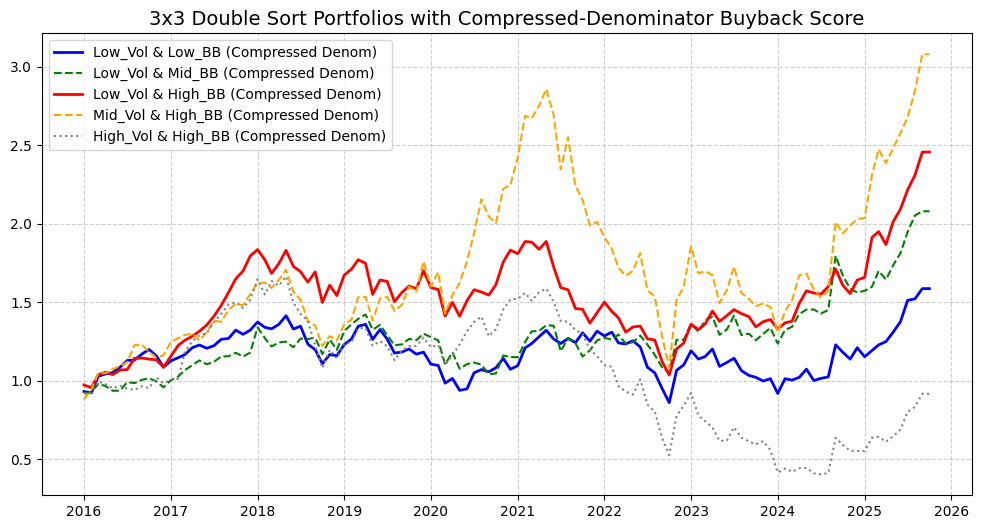

In [48]:
print("\n--- Extending: Double Sort with Compressed-Denominator Buyback Score (3x3) ---")

portfolio_returns_cd = []

for date_m, group in df_factors.groupby('date_m'):
    if date_m not in monthly_ret.index:
        continue
        
    group = group.dropna(subset=['buyback_36m', 'volatility', 'mcap', 'adtv_3m']).copy()
    if len(group) == 0:
        continue
        
    adtv_threshold = group['adtv_3m'].quantile(0.2)
    mcap_threshold = group['mcap'].quantile(0.2)
    valid_pool = group[(group['adtv_3m'] >= adtv_threshold) & (group['mcap'] >= mcap_threshold)].copy()
    pool_pos = valid_pool[valid_pool['buyback_36m'] > 0].copy()
    
    if len(pool_pos) < 9:
        continue
        
    # 压缩版分母：用 log(1 + MCap) 压缩巨无霸公司分母效应
    pool_pos['bb_score_cd'] = pool_pos['buyback_36m'] / np.log1p(pool_pos['mcap'])
    
    try:
        pool_pos['vol_q'] = pd.qcut(pool_pos['volatility'].rank(method='first'), 3, labels=['Low_Vol', 'Mid_Vol', 'High_Vol'])
        pool_pos['bb_q'] = pd.qcut(pool_pos['bb_score_cd'].rank(method='first'), 3, labels=['Low_BB', 'Mid_BB', 'High_BB'])
    except ValueError:
        continue
        
    nxt_ret = monthly_ret.loc[date_m].replace([np.inf, -np.inf], np.nan)
    ret_dict = {'date_return': date_m + 1}
    
    for v_q in ['Low_Vol', 'Mid_Vol', 'High_Vol']:
        for b_q in ['Low_BB', 'Mid_BB', 'High_BB']:
            sub_sids = pool_pos[(pool_pos['vol_q'] == v_q) & (pool_pos['bb_q'] == b_q)]['sid']
            name = f"{v_q}_{b_q}"
            
            if len(sub_sids) > 0:
                nxt_ret_sids = nxt_ret.reindex(sub_sids).fillna(0)
                if date_m in mcap_pivot.index:
                    mcap_vals = mcap_pivot.loc[date_m].reindex(sub_sids).fillna(0)
                    total_mcap = mcap_vals.sum()
                    if total_mcap > 0:
                        cw_weights = mcap_vals / total_mcap
                        MAX_W = 0.15
                        while (cw_weights > MAX_W + 1e-6).any():
                            cw_weights[cw_weights > MAX_W] = MAX_W
                            mask = cw_weights < MAX_W
                            if not mask.any(): break
                            adj = 1.0 - cw_weights[~mask].sum()
                            if adj <= 0: break
                            cw_weights[mask] = cw_weights[mask] / cw_weights[mask].sum() * adj
                        ret_dict[name] = np.sum(cw_weights.values * nxt_ret_sids.values)
                    else:
                        ret_dict[name] = nxt_ret_sids.mean()
                else:
                    ret_dict[name] = nxt_ret_sids.mean()
            else:
                ret_dict[name] = 0.0
                
    portfolio_returns_cd.append(ret_dict)

df_ds_ret_cd = pd.DataFrame(portfolio_returns_cd).set_index('date_return')

print("\n=============== 3x3 Double Sort: COMPRESSED DENOMINATOR SCORE ================")

mean_ret_cd = df_ds_ret_cd.mean() * 100
t_stats_cd = []
p_vals_cd = []
for col in df_ds_ret_cd.columns:
    y_port = df_ds_ret_cd[col].dropna() * 100
    if len(y_port) > 3:
        X_const = np.ones(len(y_port))
        mod = sm.OLS(y_port, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
        t_stats_cd.append(mod.tvalues[0])
        p_vals_cd.append(mod.pvalues[0])
    else:
        t_stats_cd.append(np.nan)
        p_vals_cd.append(np.nan)

df_summary_cd = pd.DataFrame({
    'Avg Monthly Ret (%)': mean_ret_cd.round(3),
    'T-stat (NW)': pd.Series(t_stats_cd, index=df_ds_ret_cd.columns).round(3),
    'p-value (NW)': pd.Series(p_vals_cd, index=df_ds_ret_cd.columns).round(4)
})

# FF3 alpha
common_cd = df_ds_ret_cd.index.intersection(ff3.index)
alpha_rows_cd = []
for port in ['Low_Vol_Low_BB', 'Low_Vol_Mid_BB', 'Low_Vol_High_BB', 'Mid_Vol_High_BB', 'High_Vol_High_BB']:
    if port not in df_ds_ret_cd.columns:
        continue
    y = df_ds_ret_cd.loc[common_cd, port] * 100
    X = sm.add_constant(ff3.loc[common_cd, ['MKT', 'SMB', 'HML']])
    mod = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    alpha = mod.params['const']
    p_val = mod.pvalues['const']
    t_val = mod.tvalues['const']
    stars = ''
    if p_val < 0.01:
        stars = '***'
    elif p_val < 0.05:
        stars = '**'
    elif p_val < 0.1:
        stars = '*'
    alpha_rows_cd.append({
        'Portfolio': port,
        'FF3 Alpha (%)': f"{alpha:.3f} {stars}",
        'Alpha t-stat (NW)': round(t_val, 3),
        'Alpha p-value (NW)': round(p_val, 4)
    })

df_alpha_cd = pd.DataFrame(alpha_rows_cd).set_index('Portfolio')

df_show_cd = df_summary_cd.join(df_alpha_cd, how='inner')
print("\n---- Summary Table (Compressed Denominator) ----")
print(df_show_cd.loc[['Low_Vol_Low_BB', 'Low_Vol_Mid_BB', 'Low_Vol_High_BB', 'Mid_Vol_High_BB', 'High_Vol_High_BB']])

nv_ds_cd = (1 + df_ds_ret_cd).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(nv_ds_cd.index.to_timestamp(), nv_ds_cd['Low_Vol_Low_BB'], label='Low_Vol & Low_BB (Compressed Denom)', color='blue', linewidth=2)
plt.plot(nv_ds_cd.index.to_timestamp(), nv_ds_cd['Low_Vol_Mid_BB'], label='Low_Vol & Mid_BB (Compressed Denom)', color='green', linewidth=1.5, linestyle='--')
plt.plot(nv_ds_cd.index.to_timestamp(), nv_ds_cd['Low_Vol_High_BB'], label='Low_Vol & High_BB (Compressed Denom)', color='red', linewidth=2)
plt.plot(nv_ds_cd.index.to_timestamp(), nv_ds_cd['Mid_Vol_High_BB'], label='Mid_Vol & High_BB (Compressed Denom)', color='orange', linewidth=1.5, linestyle='--')
plt.plot(nv_ds_cd.index.to_timestamp(), nv_ds_cd['High_Vol_High_BB'], label='High_Vol & High_BB (Compressed Denom)', color='gray', linewidth=1.5, linestyle=':')
plt.title('3x3 Double Sort Portfolios with Compressed-Denominator Buyback Score', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [49]:
# 收集团两组历次持仓及其收益贡献
records_ll = []
records_lh = []

# 限制市值权重函数 (与前面回测时保持一致)
def get_cw_weights(sids_subset, d_m):
    if d_m not in mcap_pivot.index:
        return np.ones(len(sids_subset)) / len(sids_subset)
    m_vals = mcap_pivot.loc[d_m].reindex(sids_subset).fillna(0)
    tot = m_vals.sum()
    if tot <= 0:
        return np.ones(len(sids_subset)) / len(sids_subset)
    cw = (m_vals / tot).values
    MAX_W = 0.15
    while (cw > MAX_W + 1e-6).any():
        cw[cw > MAX_W] = MAX_W
        mask = cw < MAX_W
        if not mask.any():
            break
        adj = 1.0 - cw[~mask].sum()
        if adj <= 0:
            break
        cw[mask] = cw[mask] / cw[mask].sum() * adj
    return cw

for date_m, group in df_factors.groupby('date_m'):
    if date_m not in monthly_ret.index:
        continue

    group = group.dropna(subset=['buyback_36m', 'volatility', 'mcap', 'adtv_3m']).copy()
    if len(group) == 0:
        continue

    adtv_thr = group['adtv_3m'].quantile(0.2)
    mcap_thr = group['mcap'].quantile(0.2)
    valid_pool = group[(group['adtv_3m'] >= adtv_thr) & (group['mcap'] >= mcap_thr)]

    pool_pos = valid_pool[valid_pool['buyback_36m'] > 0].copy()

    if len(pool_pos) < 9:
        continue

    # 当前使用的回购因子：压缩版分母口径
    pool_pos['bb_score_cd'] = pool_pos['buyback_36m'] / np.log1p(pool_pos['mcap'])

    try:
        pool_pos['vol_q'] = pd.qcut(pool_pos['volatility'].rank(method='first'), 3, labels=['Low_Vol', 'Mid_Vol', 'High_Vol'])
        pool_pos['bb_q'] = pd.qcut(pool_pos['bb_score_cd'].rank(method='first'), 3, labels=['Low_BB', 'Mid_BB', 'High_BB'])
    except ValueError:
        continue

    nxt_r = monthly_ret.loc[date_m].replace([np.inf, -np.inf], np.nan)

    # 提取 Low_Vol_Low_BB
    sids_ll = pool_pos[(pool_pos['vol_q'] == 'Low_Vol') & (pool_pos['bb_q'] == 'Low_BB')]['sid']
    if len(sids_ll) > 0:
        r_ll = nxt_r.reindex(sids_ll).fillna(0).values
        w_ll = get_cw_weights(sids_ll, date_m)
        for s, w, r in zip(sids_ll, w_ll, r_ll):
            records_ll.append({'sid': s, 'weight': w, 'ret': r, 'contrib': w * r})

    # 提取 Low_Vol_High_BB
    sids_lh = pool_pos[(pool_pos['vol_q'] == 'Low_Vol') & (pool_pos['bb_q'] == 'High_BB')]['sid']
    if len(sids_lh) > 0:
        r_lh = nxt_r.reindex(sids_lh).fillna(0).values
        w_lh = get_cw_weights(sids_lh, date_m)
        for s, w, r in zip(sids_lh, w_lh, r_lh):
            records_lh.append({'sid': s, 'weight': w, 'ret': r, 'contrib': w * r})

# 构建由 sid 映射到 股票名称 的字典 (从 buyback 数据表中提取)
name_map = dict(zip(buyback['sid'], buyback['股票名称']))

# 统计并打印函数
def print_top_holdings_stats(records, title):
    df_rec = pd.DataFrame(records)
    if len(df_rec) == 0:
        print(f"============== {title} ==============")
        print("No holdings found")
        print("\n")
        return

    grp = df_rec.groupby('sid').agg(
        Freq=('sid', 'count'),
        Avg_Weight=('weight', 'mean'),
        Ann_Ret=('ret', lambda x: x.mean() * 12 * 100),
        Total_Contrib=('contrib', lambda x: x.sum() * 100)
    ).sort_values('Freq', ascending=False).head(15)

    grp['Company Name'] = grp.index.map(lambda x: name_map.get(x, 'Unknown'))
    grp['Avg_Wgt'] = grp['Avg_Weight'].apply(lambda x: f"{x * 100:.1f}%")
    grp['Holding_Ann_Ret'] = grp['Ann_Ret'].apply(lambda x: f"{x:.2f}%")
    grp['Total_Contrib'] = grp['Total_Contrib'].apply(lambda x: f"{x:.2f}%")

    print(f"============== {title} ==============")
    print(grp[['Company Name', 'Freq', 'Avg_Wgt', 'Holding_Ann_Ret', 'Total_Contrib']])
    print("\n")

print_top_holdings_stats(records_ll, "Top 15 Holdings Frequent in Low_Vol & Low_BB")
print_top_holdings_stats(records_lh, "Top 15 Holdings Frequent in Low_Vol & High_BB")

============== Top 15 Holdings Frequent in Low_Vol & Low_BB ==============
        Company Name  Freq Avg_Wgt Holding_Ann_Ret Total_Contrib
sid                                                             
0683.HK         嘉里建设    71    9.5%          13.30%         7.17%
0392.HK         北京控股    54   10.2%           1.67%        -1.17%
0003.HK       香港中华煤气    51   15.0%          12.58%         8.02%
1448.HK          福寿园    51    5.9%           6.80%         0.31%
0371.HK       北控水务集团    43   10.5%          -5.94%        -4.40%
1800.HK       中国交通建设    38   14.7%           6.10%         2.61%
0006.HK         电能实业    37   14.8%          13.77%         6.14%
3311.HK       中国建筑国际    36   11.8%          38.19%        16.12%
0152.HK         深圳国际    36   12.8%          -6.92%        -3.41%
0083.HK         信和置业    33   15.0%          -3.12%        -1.29%
0168.HK       青岛啤酒股份    31   13.3%         -15.82%        -6.68%
0019.HK      太古股份公司A    30   15.0%           9.44%         3.54%
0363.HK       上